In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cuda,cpu"   # prefer CUDA, fall back to CPU
# os.environ["CUDA_VISIBLE_DEVICES"] = ""  # keep commented if you want GPU

import pickle
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import lax
import jax.tree_util as tree_util
from functools import partial

import numpy as onp

import torch

print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())


JAX backend: gpu
JAX devices: [cuda(id=0)]


In [20]:
# ============================================================
# Inverse DeepONet Training (sparse Mach -> Area)
# Robust to sensor placement via (M_sparse, mask)
# ============================================================

DATA_FILE  = "deeponet_nozzle_dataset.npz"

# Train counts 
TRAIN_NOBS = [10, 40, 100]

# What you print during training 
REPORT_NOBS = [5, 10, 15, 20, 25, 30, 40, 50, 60, 80, 90, 100]

# Sensor placement patterns used in training
PATTERNS = ("uniform", "jittered_uniform", "random")

SEED       = 0
P_LATENT   = 64
LR         = 1e-3
BATCH_SIZE = 32
N_EPOCHS   = 10000
REPORT_EVERY = 100

# =========================
# Load dataset
# =========================
data = np.load(DATA_FILE, allow_pickle=True)

x       = jnp.asarray(data["x"], dtype=jnp.float32)         # (N,)
A_train = jnp.asarray(data["A_train"], dtype=jnp.float32)   # (Ntr, N)
M_train = jnp.asarray(data["M_train"], dtype=jnp.float32)   # (Ntr, N)
A_val   = jnp.asarray(data["A_val"], dtype=jnp.float32)     # (Nva, N)
M_val   = jnp.asarray(data["M_val"], dtype=jnp.float32)     # (Nva, N)

Ntr, N = A_train.shape
Nva = A_val.shape[0]

print("Shapes:", A_train.shape, M_train.shape, A_val.shape, M_val.shape)
print("TRAIN_NOBS:", TRAIN_NOBS)
print("REPORT_NOBS:", REPORT_NOBS)
print("PATTERNS:", PATTERNS)


Shapes: (1500, 101) (1500, 101) (500, 101) (500, 101)
TRAIN_NOBS: [10, 40, 100]
REPORT_NOBS: [5, 10, 15, 20, 25, 30, 40, 50, 60, 80, 90, 100]
PATTERNS: ('uniform', 'jittered_uniform', 'random')


In [ ]:
# =========================
# Normalization
# =========================
M_all = jnp.concatenate([M_train, M_val], axis=0)
mu_M  = jnp.mean(M_all)
std_M = jnp.std(M_all) + 1e-6

A_all = jnp.concatenate([A_train, A_val], axis=0)
mu_A  = jnp.mean(A_all)
std_A = jnp.std(A_all) + 1e-6

x_min = float(x[0])
x_max = float(x[-1])

def normalize_x(x_grid):
    # map [x_min, x_max] -> [-1, 1]
    return 2.0 * ((x_grid - x_min) / (x_max - x_min) - 0.5)

# =========================
# Sensor pattern helpers
# =========================
def obs_uniform(N, Nobs):
    idx = np.linspace(0, N - 1, Nobs).round().astype(np.int32)
    return np.unique(idx)

def obs_random(N, Nobs, rng, include_endpoints=True):
    if include_endpoints and Nobs >= 2:
        interior = rng.choice(np.arange(1, N - 1), size=Nobs - 2, replace=False)
        idx = np.sort(np.concatenate([[0], interior, [N - 1]]))
        return idx.astype(np.int32)
    idx = np.sort(rng.choice(np.arange(N), size=Nobs, replace=False))
    return idx.astype(np.int32)

def obs_jittered_uniform(N, Nobs, rng, jitter_frac=0.35):
    base = obs_uniform(N, Nobs)
    if base.size <= 2:
        return base
    idx = base.copy()
    for k in range(1, len(idx) - 1):
        left  = idx[k] - idx[k - 1]
        right = idx[k + 1] - idx[k]
        h = max(1, min(left, right))
        max_jit = max(1, int(jitter_frac * h))
        idx[k] = np.clip(idx[k] + rng.integers(-max_jit, max_jit + 1), 0, N - 1)
    idx = np.unique(idx)
    while idx.size < Nobs:
        idx = np.unique(np.append(idx, rng.integers(0, N)))
    return np.sort(idx[:Nobs]).astype(np.int32)

def sample_pattern(N, Nobs, rng):
    pat = rng.choice(PATTERNS)
    if pat == "uniform":
        return obs_uniform(N, Nobs), pat
    if pat == "random":
        return obs_random(N, Nobs, rng, include_endpoints=True), pat
    if pat == "jittered_uniform":
        return obs_jittered_uniform(N, Nobs, rng), pat
    raise ValueError(pat)

def make_sparse_and_mask(M_full, idx, N):
    Msp = np.zeros((N,), dtype=np.float32)
    mk  = np.zeros((N,), dtype=np.float32)
    Msp[idx] = np.asarray(M_full)[idx]
    mk[idx]  = 1.0
    return Msp, mk

# =========================
# DeepONet definition
# =========================
def init_layer(key, in_dim, out_dim):
    W = jax.random.normal(key, (in_dim, out_dim)) * jnp.sqrt(2.0 / in_dim)
    b = jnp.zeros((out_dim,))
    return (W, b)

def init_mlp(sizes, key):
    params = []
    keys = jax.random.split(key, len(sizes) - 1)
    for (m, n), k in zip(zip(sizes[:-1], sizes[1:]), keys):
        params.append(init_layer(k, m, n))
    return params

def mlp_apply(params, x):
    for (W, b) in params[:-1]:
        x = jnp.tanh(x @ W + b)
    W_last, b_last = params[-1]
    return x @ W_last + b_last

def init_inv_deeponet(key, n_grid, p=64, hidden_branch=(128,128), hidden_trunk=(64,64)):
    kb, kt = jax.random.split(key, 2)
    branch_sizes = (2 * n_grid,) + hidden_branch + (p,)
    trunk_sizes  = (1,)         + hidden_trunk  + (p,)
    return {
        "branch": init_mlp(branch_sizes, kb),
        "trunk":  init_mlp(trunk_sizes,  kt),
        "bias":   jnp.array(0.0),
    }

def inv_apply_single(params, M_sparse, mask, x_grid):
    # normalize M only; mask stays {0,1}
    M_n = (M_sparse - mu_M) / std_M
    z = jnp.concatenate([M_n, mask], axis=0)[None, :]     # (1,2N)
    x_n = normalize_x(x_grid)[:, None]                    # (N,1)

    b_feat = mlp_apply(params["branch"], z)[0]            # (p,)
    t_feat = mlp_apply(params["trunk"],  x_n)             # (N,p)

    A_pred_n = jnp.sum(t_feat * b_feat[None, :], axis=1) + params["bias"]
    return A_pred_n * std_A + mu_A

inv_apply_single_jit = jax.jit(inv_apply_single)

def inv_apply_batch(params, Msp_b, mk_b, x_grid):
    return jax.vmap(lambda m, k: inv_apply_single_jit(params, m, k, x_grid))(Msp_b, mk_b)

# =========================
# Adam optimizer (pure JAX)
# =========================
def tree_zeros_like(tree):
    return tree_util.tree_map(jnp.zeros_like, tree)

def adam_init(params):
    return {"m": tree_zeros_like(params), "v": tree_zeros_like(params), "t": jnp.array(0, jnp.int32)}

def adam_update(params, grads, opt_state, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
    t = opt_state["t"] + 1
    m = tree_util.tree_map(lambda m, g: b1*m + (1-b1)*g, opt_state["m"], grads)
    v = tree_util.tree_map(lambda v, g: b2*v + (1-b2)*(g*g), opt_state["v"], grads)

    m_hat = tree_util.tree_map(lambda m: m / (1 - b1**t), m)
    v_hat = tree_util.tree_map(lambda v: v / (1 - b2**t), v)

    params_new = tree_util.tree_map(lambda p, mh, vh: p - lr*mh/(jnp.sqrt(vh)+eps), params, m_hat, v_hat)
    return params_new, {"m": m, "v": v, "t": t}

def mse_loss(params, Msp_b, mk_b, Atrue_b, x_grid):
    Apred = inv_apply_batch(params, Msp_b, mk_b, x_grid)
    return jnp.mean((Apred - Atrue_b) ** 2)

@jax.jit
def train_step(params, opt_state, Msp_b, mk_b, Atrue_b, x_grid):
    loss, grads = jax.value_and_grad(lambda p: mse_loss(p, Msp_b, mk_b, Atrue_b, x_grid))(params)
    params_new, opt_state_new = adam_update(params, grads, opt_state, lr=LR)
    return params_new, opt_state_new, loss

# =========================
# Batch builder 
# =========================
def build_batch(M_full_batch, A_true_batch, rng):
    M_full_np = np.asarray(M_full_batch)
    A_true_np = np.asarray(A_true_batch)

    B = M_full_np.shape[0]
    Msp = np.zeros((B, N), dtype=np.float32)
    mk  = np.zeros((B, N), dtype=np.float32)

    for i in range(B):
        nobs = int(rng.choice(TRAIN_NOBS))
        idx, _ = sample_pattern(N, nobs, rng)
        msi, mki = make_sparse_and_mask(M_full_np[i], idx, N)
        Msp[i] = msi
        mk[i]  = mki

    return jnp.asarray(Msp), jnp.asarray(mk), jnp.asarray(A_true_np)

# =========================
# Validation evaluation 
# =========================
def eval_mse(params, Nobs, pattern="uniform"):
    rng = np.random.default_rng(12345)
    Msp_list, mk_list = [], []

    for i in range(Nva):
        if pattern == "uniform":
            idx = obs_uniform(N, Nobs)
        elif pattern == "random":
            idx = obs_random(N, Nobs, rng)
        elif pattern == "jittered_uniform":
            idx = obs_jittered_uniform(N, Nobs, rng)
        else:
            raise ValueError(pattern)

        msi, mki = make_sparse_and_mask(np.asarray(M_val[i]), idx, N)
        Msp_list.append(msi)
        mk_list.append(mki)

    Msp_v = jnp.asarray(np.stack(Msp_list, axis=0))
    mk_v  = jnp.asarray(np.stack(mk_list, axis=0))
    Apred = inv_apply_batch(params, Msp_v, mk_v, x)
    return float(jnp.mean((Apred - A_val) ** 2))

# =========================
# Train loop
# =========================
rng = np.random.default_rng(SEED)

key = jax.random.PRNGKey(SEED)
params = init_inv_deeponet(key, n_grid=N, p=P_LATENT)
opt_state = adam_init(params)

n_batches = Ntr // BATCH_SIZE

train_hist, val_hist, epoch_hist = [], [], []
best_val = np.inf

for epoch in range(1, N_EPOCHS + 1):
    perm = rng.permutation(Ntr)
    A_tr = A_train[perm]
    M_tr = M_train[perm]

    ep_loss = 0.0
    for bi in range(n_batches):
        Mb = M_tr[bi*BATCH_SIZE:(bi+1)*BATCH_SIZE]
        Ab = A_tr[bi*BATCH_SIZE:(bi+1)*BATCH_SIZE]
        Msp_b, mk_b, Atrue_b = build_batch(Mb, Ab, rng)

        params, opt_state, loss = train_step(params, opt_state, Msp_b, mk_b, Atrue_b, x)
        ep_loss += float(loss)

    ep_loss /= n_batches

    if epoch == 1 or (epoch % REPORT_EVERY == 0):
        # report across a range (including held-out counts)
        report = {n: eval_mse(params, int(n), pattern="uniform") for n in REPORT_NOBS}

        # model selection: ONLY average over TRAIN_NOBS
        val_avg_train = float(np.mean([report[n] for n in TRAIN_NOBS]))

        print(
            f"[Epoch {epoch:04d}] train={ep_loss:.3e} | val(avg TRAIN_NOBS)={val_avg_train:.3e} | "
            + " ".join([f"val{n}={report[n]:.2e}" for n in REPORT_NOBS])
        )

        train_hist.append(ep_loss)
        val_hist.append(val_avg_train)
        epoch_hist.append(epoch)

        if val_avg_train < best_val:
            best_val = val_avg_train
            with open("inv_deeponet_params_best.pkl", "wb") as f:
                pickle.dump(params, f)
            np.savez(
                "inv_deeponet_meta.npz",
                mu_M=np.array(mu_M), std_M=np.array(std_M),
                mu_A=np.array(mu_A), std_A=np.array(std_A),
                x_min=np.array(x_min), x_max=np.array(x_max),
                N=np.array(N), p=np.array(P_LATENT),
                TRAIN_NOBS=np.array(TRAIN_NOBS),
                PATTERNS=np.array(PATTERNS, dtype=object),
            )

np.savez(
    "inv_deeponet_loss_history.npz",
    epoch=np.array(epoch_hist),
    train=np.array(train_hist),
    val=np.array(val_hist),
    best_val=np.array(best_val),
)

print("Saved:")
print(" - inv_deeponet_params_best.pkl")
print(" - inv_deeponet_meta.npz")
print(" - inv_deeponet_loss_history.npz")

plt.figure(figsize=(6,4))
plt.semilogy(epoch_hist, train_hist, label="Train MSE")
plt.semilogy(epoch_hist, val_hist, label="Val MSE (avg over TRAIN_NOBS)")
plt.xlabel("Epoch"); plt.ylabel("MSE (log)")
plt.grid(alpha=0.3); plt.legend()
plt.tight_layout()
plt.show()


In [12]:

# ------------------ Forward solver (JAX CFD) ------------------
def DeltaCal_jnp(x):
    dx = jnp.zeros_like(x)
    dx = dx.at[:-1].set(x[1:] - x[:-1])
    dx = dx.at[-1].set(dx[-2])
    return dx

def EnergyCal_jnp(rho, u, P, gamma):
    return P / (gamma - 1.0) + 0.5 * rho * u**2

def ConservCal_jnp(rho, u, E, A):
    Q0 = rho * A
    Q1 = rho * u * A
    Q2 = E   * A
    return jnp.stack([Q0, Q1, Q2], axis=0)

def PrimCal_jnp(Q, A):
    rho = Q[0] / A
    u   = Q[1] / Q[0]
    E   = Q[2] / A
    return rho, u, E

def PressureCal_jnp(rho, u, E, gamma):
    return (gamma - 1.0) * (E - 0.5 * rho * u**2)

def FluxSplitCal_vec_jnp(rho, u, P, E, A, dAdx, gamma):
    N = u.size
    zeros = jnp.zeros(N)
    c = jnp.sqrt(jnp.abs(gamma * P / rho))
    M = u / c

    mask_sub     = jnp.abs(M) < 1.0
    mask_le_neg1 = M <= -1.0
    mask_gt_pos1 = M >  1.0

    PP  = jnp.where(mask_sub, 0.5*(1+M)*P, 0.0)
    PN  = jnp.where(mask_sub, 0.5*(1-M)*P, 0.0)
    PuP = jnp.where(mask_sub, 0.5*(u+c)*P, 0.0)
    PuN = jnp.where(mask_sub, 0.5*(u-c)*P, 0.0)

    PP  = jnp.where(mask_gt_pos1, P,  PP)
    PuP = jnp.where(mask_gt_pos1, u*P, PuP)
    PN  = jnp.where(mask_le_neg1, P,  PN)
    PuN = jnp.where(mask_le_neg1, u*P, PuN)

    Fp0 = jnp.where(u>0, rho*u*A, 0.0)
    Fp1 = jnp.where(u>0, (rho*u**2+PP)*A, PP*A)
    Fp2 = jnp.where(u>0, (u*E+PuP)*A,    PuP*A)

    Fn0 = jnp.where(u<0, rho*u*A, 0.0)
    Fn1 = jnp.where(u<0, (rho*u**2+PN)*A, PN*A)
    Fn2 = jnp.where(u<0, (u*E+PuN)*A,    PuN*A)

    FP = jnp.stack([Fp0, Fp1, Fp2], axis=0)
    FN = jnp.stack([Fn0, Fn1, Fn2], axis=0)
    H  = jnp.stack([zeros, P*dAdx, zeros], axis=0)
    return FP, FN, H

def TimeStep_jnp(dx, rho, u, P, cfl, gamma):
    c = jnp.sqrt(jnp.abs(gamma * P / rho))
    cmax = jnp.max(jnp.abs(u) + c)
    return cfl * dx[1] / cmax

@partial(jax.jit, static_argnames=("gamma",))
def apply_bc(rho, u, P, E, gamma):
    # inlet (supersonic)
    rho = rho.at[0].set(0.5008261)
    u   = u.at[0].set(1.0991840)
    P   = P.at[0].set(0.2712900)
    E   = E.at[0].set(EnergyCal_jnp(rho[0], u[0], P[0], gamma))

    # outlet (subsonic: fixed P, extrapolated rho,u)
    rho = rho.at[-1].set(2.0 * rho[-2] - rho[-3])
    u   = u.at[-1].set(2.0 * u[-2]   - u[-3])
    P   = P.at[-1].set(0.5156000)
    E   = E.at[-1].set(EnergyCal_jnp(rho[-1], u[-1], P[-1], gamma))
    return rho, u, P, E

def upwind_update_vec_jnp(Q, A, dAdx, dx, gamma, dt):
    rho, u, E = PrimCal_jnp(Q, A)
    P = PressureCal_jnp(rho, u, E, gamma)
    rho, u, P, E = apply_bc(rho, u, P, E, gamma)
    Q = ConservCal_jnp(rho, u, E, A)
    FP, FN, H = FluxSplitCal_vec_jnp(rho, u, P, E, A, dAdx, gamma)

    def update_col(i, Q):
        Qi = Q[:, i]
        dF = (FP[:, i] - FP[:, i-1] + FN[:, i+1] - FN[:, i])
        Qi_new = Qi - (dt / dx[i]) * dF + dt * H[:, i]
        return Q.at[:, i].set(Qi_new)

    N = A.size
    Q_new = lax.fori_loop(1, N-1, update_col, Q)
    return Q_new

@partial(jax.jit, static_argnames=("n_steps","gamma","cfl"))
def forward_only_jax(x, A, n_steps=5000, gamma=1.4, cfl=0.9):
    x = jnp.asarray(x); A = jnp.asarray(A)
    N = A.size

    dAdx0  = (A[1]  - A[0])  / (x[1]  - x[0])
    dAdxN1 = (A[-1] - A[-2]) / (x[-1] - x[-2])
    dAdx_mid = (A[2:] - A[:-2]) / (x[2:] - x[:-2])
    dAdx = jnp.concatenate([dAdx0[None], dAdx_mid, dAdxN1[None]])

    dx = DeltaCal_jnp(x)

    rho = jnp.ones(N) * 0.7511383
    u   = jnp.ones(N) * 0.4416178
    P   = jnp.ones(N) * 0.2156000
    E   = EnergyCal_jnp(rho, u, P, gamma)
    Q   = ConservCal_jnp(rho, u, E, A)

    def body_fun(step, Q):
        rho0, u0, E0 = PrimCal_jnp(Q, A)
        P0 = PressureCal_jnp(rho0, u0, E0, gamma)
        dt = TimeStep_jnp(dx, rho0, u0, P0, cfl, gamma)
        return upwind_update_vec_jnp(Q, A, dAdx, dx, gamma, dt)

    Q = lax.fori_loop(0, n_steps, body_fun, Q)

    rho, u, E = PrimCal_jnp(Q, A)
    P = PressureCal_jnp(rho, u, E, gamma)
    c = jnp.sqrt(jnp.abs(gamma * P / rho))
    M = u / c
    return rho, u, P, M



In [13]:
# ============================================================
# Load trained Inverse DeepONet (sparse Mach + mask -> Area)
# Files expected:
#   - inv_deeponet_params_best.pkl
#   - inv_deeponet_meta.npz
#   - deeponet_nozzle_dataset.npz 
# ============================================================
# -----------------------------
# Load trained params + meta
# -----------------------------
PARAMS_FILE = "inv_deeponet_params_best.pkl"
META_FILE   = "inv_deeponet_meta.npz"

with open(PARAMS_FILE, "rb") as f:
    params = pickle.load(f)

meta = np.load(META_FILE, allow_pickle=True)

mu_M   = jnp.array(meta["mu_M"], dtype=jnp.float32).reshape(())
std_M  = jnp.array(meta["std_M"], dtype=jnp.float32).reshape(())
mu_A   = jnp.array(meta["mu_A"], dtype=jnp.float32).reshape(())
std_A  = jnp.array(meta["std_A"], dtype=jnp.float32).reshape(())
x_min  = float(meta["x_min"])
x_max  = float(meta["x_max"])
N_meta = int(meta["N"])
p_lat  = int(meta["p"])

# saved training config info 
TRAIN_NOBS = meta.get("TRAIN_NOBS", None)
PATTERNS   = meta.get("PATTERNS", None)

print(f"Loaded meta: N={N_meta}, p={p_lat}, x∈[{x_min},{x_max}]")
if TRAIN_NOBS is not None:
    print("TRAIN_NOBS:", TRAIN_NOBS.tolist())
if PATTERNS is not None:
    print("PATTERNS:", list(PATTERNS))


def normalize_x(x_grid):
    # map [x_min, x_max] -> [-1, 1]
    return 2.0 * ((x_grid - x_min) / (x_max - x_min) - 0.5)

def mlp_apply(mlp_params, x):
    # mlp_params = [(W,b), (W,b), ...]
    for (W, b) in mlp_params[:-1]:
        x = jnp.tanh(x @ W + b)
    W_last, b_last = mlp_params[-1]
    return x @ W_last + b_last

def inv_apply_single(params, M_sparse, mask, x_grid):
    """
    params: dict with keys ["branch","trunk","bias"]
    M_sparse: (N,) float32, with zeros at unobserved locations
    mask:     (N,) float32, 1 at observed, 0 else
    x_grid:   (N,) float32
    returns:  (N,) predicted A(x)
    """
    # normalize M only; mask stays {0,1}
    M_n = (M_sparse - mu_M) / std_M
    z   = jnp.concatenate([M_n, mask], axis=0)[None, :]    # (1, 2N)
    x_n = normalize_x(x_grid)[:, None]                     # (N,1)

    b_feat = mlp_apply(params["branch"], z)[0]             # (p,)
    t_feat = mlp_apply(params["trunk"],  x_n)              # (N,p)

    A_pred_n = jnp.sum(t_feat * b_feat[None, :], axis=1) + params["bias"]
    return A_pred_n * std_A + mu_A

inv_apply_single_jit = jax.jit(inv_apply_single)

# batch apply
inv_apply_batch_jit = jax.jit(
    lambda params, Msp_b, mk_b, xg: jax.vmap(lambda m, k: inv_apply_single(params, m, k, xg))(Msp_b, mk_b)
)

print("Model loaded and apply functions are ready.")

# -----------------------------
# Quick sanity test 
# -----------------------------

try:
    DATA_FILE = "deeponet_nozzle_dataset.npz"
    data = np.load(DATA_FILE, allow_pickle=True)
    x = jnp.asarray(data["x"], dtype=jnp.float32)          # (N,)
    M_val = jnp.asarray(data["M_val"], dtype=jnp.float32)  # (Nva,N)
    A_val = jnp.asarray(data["A_val"], dtype=jnp.float32)  # (Nva,N)

    assert x.shape[0] == N_meta, f"x has N={x.shape[0]} but meta says N={N_meta}"

    # build a toy sparse observation from one validation sample
    i = 0
    M_full = np.asarray(M_val[i])
    N = M_full.size

    # simple uniform sensors
    Nobs = 20
    idx = np.linspace(0, N - 1, Nobs).round().astype(np.int32)

    Msp = np.zeros((N,), dtype=np.float32)
    mk  = np.zeros((N,), dtype=np.float32)
    Msp[idx] = M_full[idx]
    mk[idx]  = 1.0

    A_pred = np.asarray(inv_apply_single_jit(params,
                                             jnp.array(Msp, dtype=jnp.float32),
                                             jnp.array(mk,  dtype=jnp.float32),
                                             x))

    A_true = np.asarray(A_val[i])
    rmse = float(np.sqrt(np.mean((A_pred - A_true) ** 2)))
    print(f"[Sanity test] Nobs={Nobs} uniform -> RMSE={rmse:.3e}")

except FileNotFoundError:
    print("Dataset file not found (deeponet_nozzle_dataset.npz). Skipping sanity test.")

Loaded meta: N=101, p=64, x∈[0.0,10.0]
TRAIN_NOBS: [10, 40, 100]
PATTERNS: ['uniform', 'jittered_uniform', 'random']
Model loaded and apply functions are ready.
[Sanity test] Nobs=20 uniform -> RMSE=1.599e-01


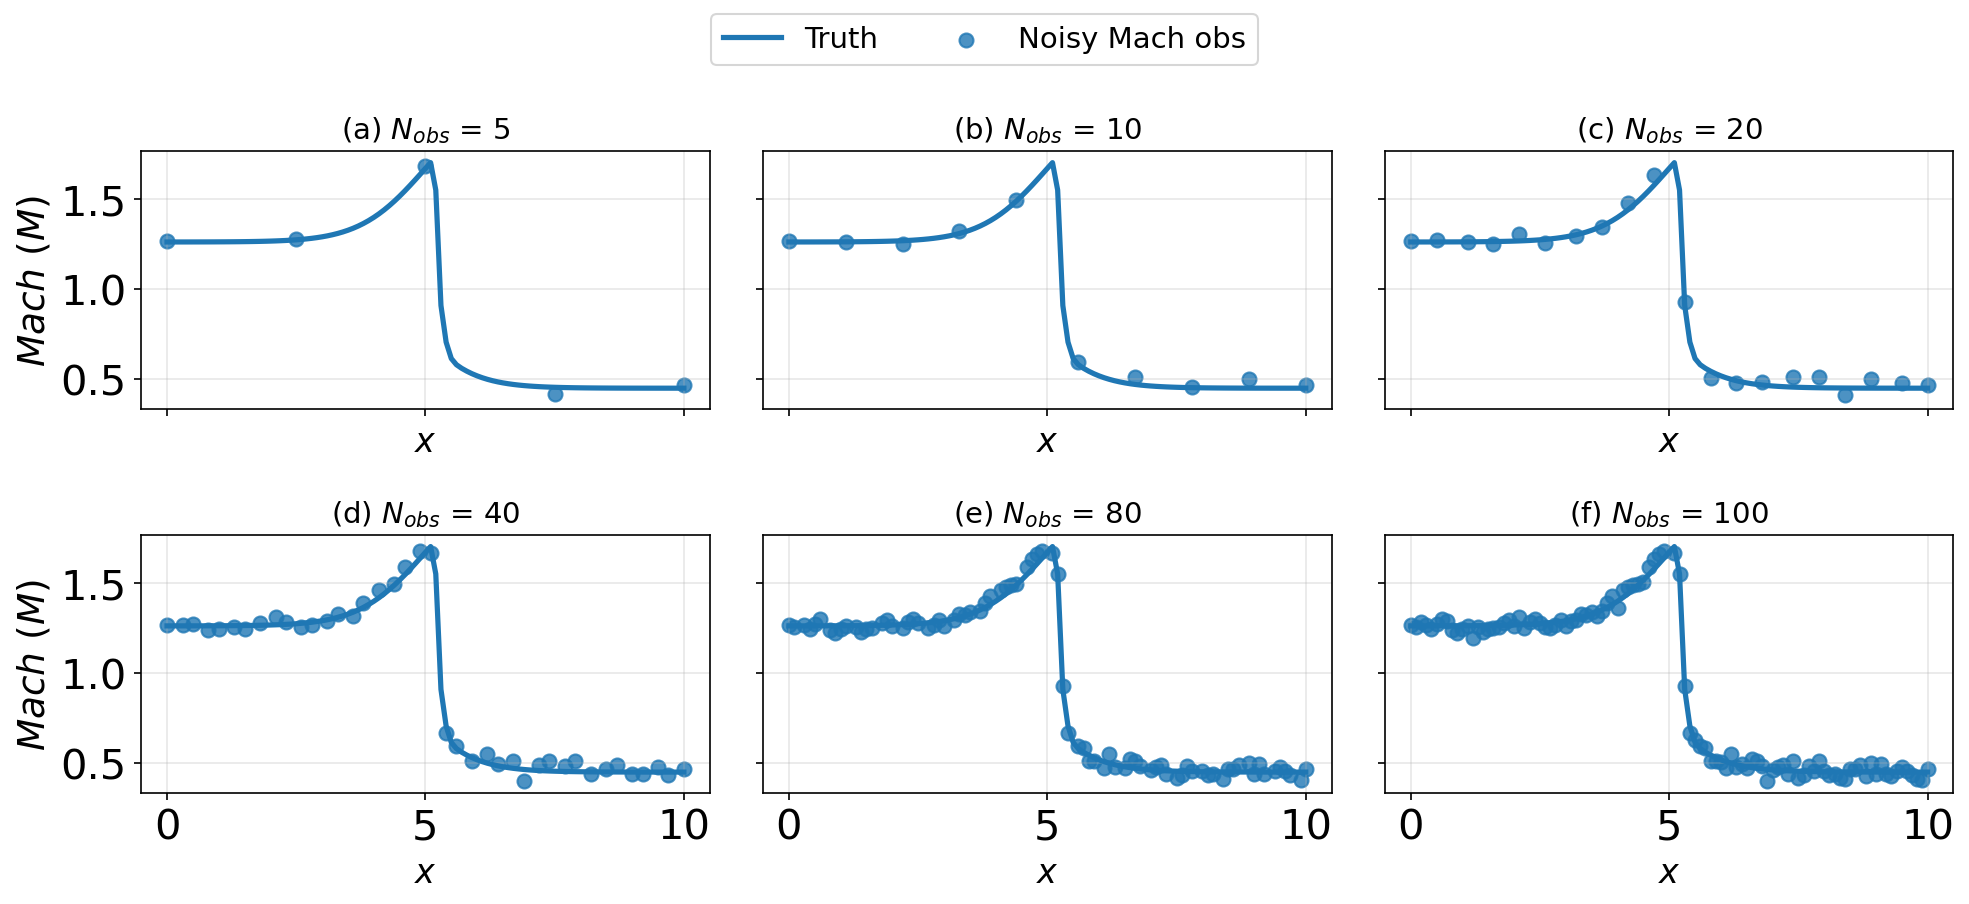

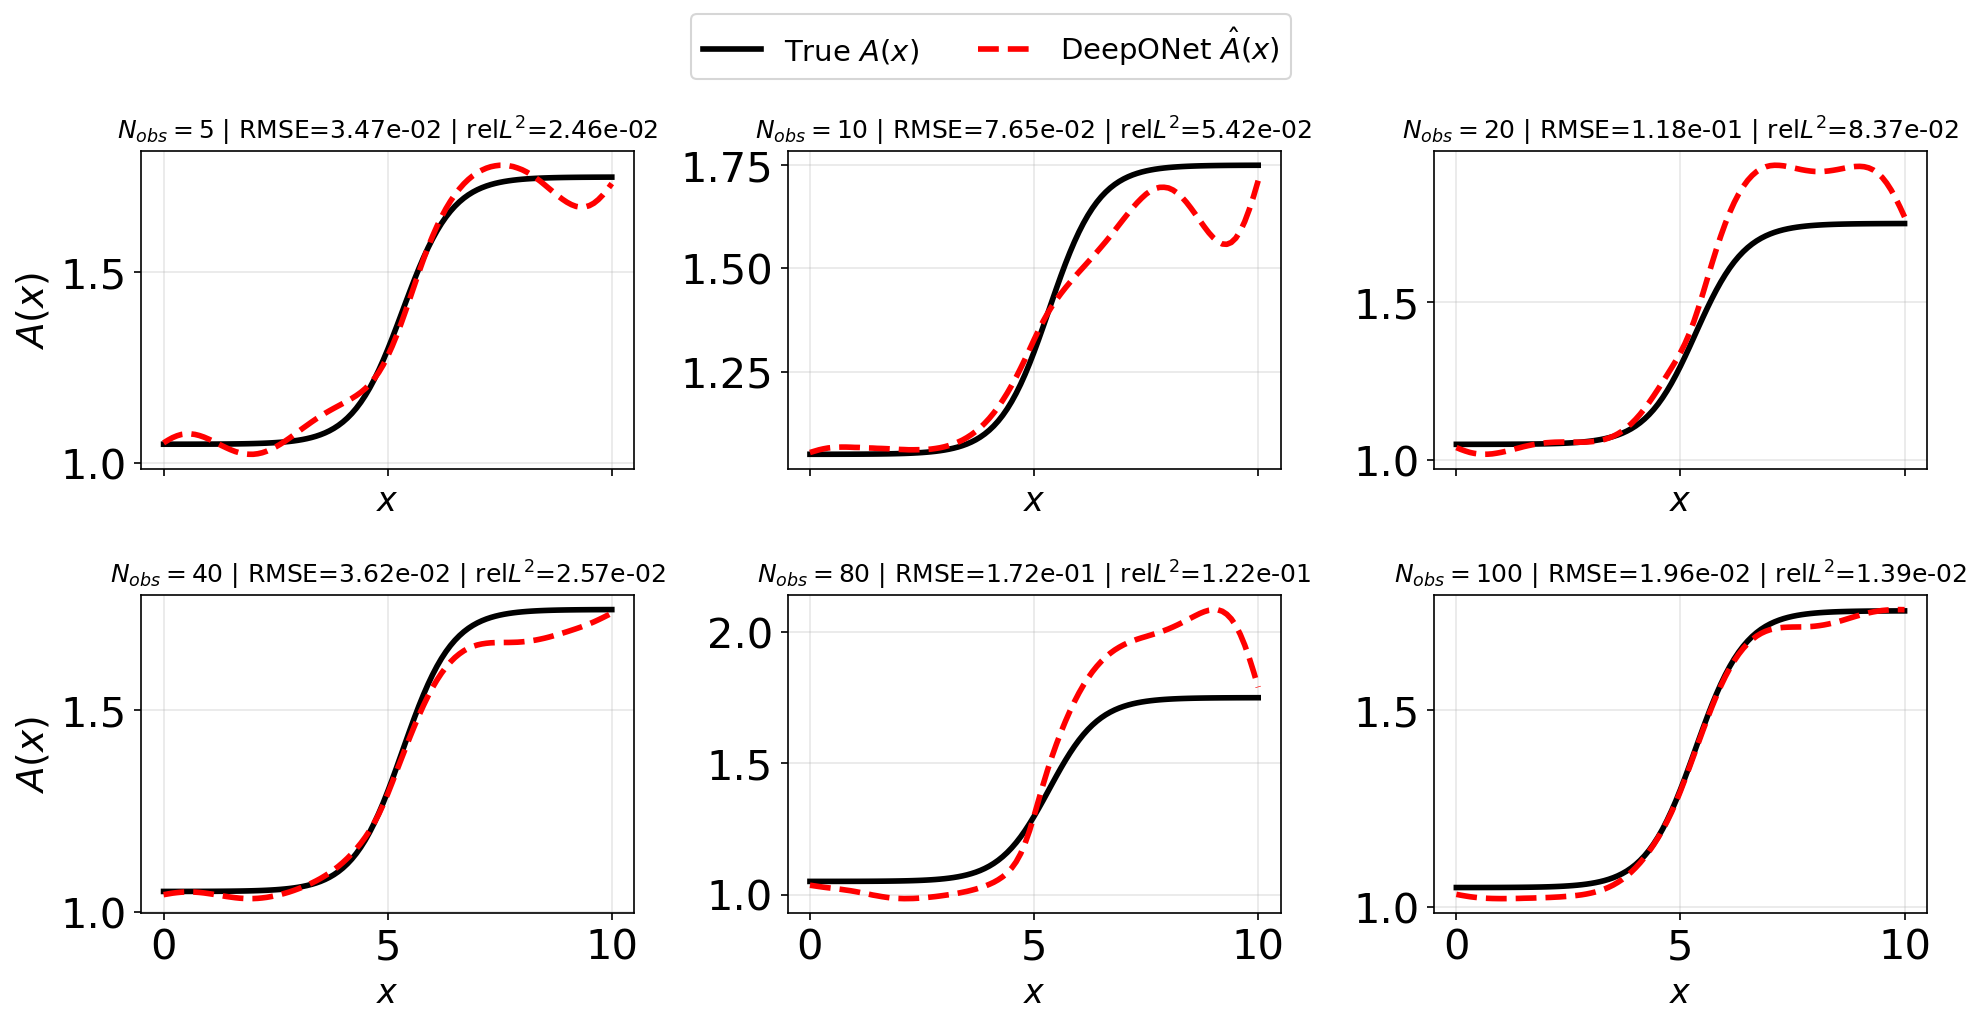

In [14]:
# ============================================================
# 3x2 observation panels (Mach) + 3x2 reconstruction panels (A)
# Sensor style matches your example: scatter at sensor locations
# ============================================================


# -----------------------------
# Sensor helpers
# -----------------------------
def obs_indices_uniform(N, Nobs):
    idx = np.linspace(0, N - 1, int(Nobs)).round().astype(np.int32)
    idx = np.unique(idx)
    if idx.size < Nobs:
        extra = np.setdiff1d(np.arange(N), idx)
        take = extra[np.linspace(0, len(extra)-1, Nobs-idx.size).round().astype(int)]
        idx = np.sort(np.unique(np.concatenate([idx, take])))
    return idx[:Nobs]

def make_sparse_and_mask(M_full, idx, N):
    M_full = np.asarray(M_full)
    Msp = np.zeros((N,), dtype=np.float32)
    mk  = np.zeros((N,), dtype=np.float32)
    Msp[idx] = M_full[idx]
    mk[idx]  = 1.0
    return Msp, mk

# -----------------------------
# Build physics test case
# -----------------------------
x_np = np.asarray(x, dtype=np.float32)
N = x_np.size


def A_true_fn(x):
    return 1.05 + 0.70 * (0.5 * (1.0 + np.tanh(0.9 * x - 4.8)))  # smooth throat-to-exit growth
A_true_np = A_true_fn(x_np).astype(np.float32)

# Forward solve Mach truth from this A_true
_, _, _, M_true_jnp = forward_only_jax(jnp.asarray(x_np), jnp.asarray(A_true_np))
M_true = np.asarray(M_true_jnp, dtype=np.float32)

# Add noise to emulate "Noisy Mach obs"
sigma = 0.03
rng = np.random.default_rng(0)
M_obs_full = (M_true + sigma * rng.standard_normal(size=M_true.shape)).astype(np.float32)

# -----------------------------
# Evaluate inverse reconstructions at desired Nobs
# -----------------------------
TEST_NOBS = [5, 10, 20, 40, 80, 100]

results = []  # store per-panel outputs

for Nobs in TEST_NOBS:
    idx = obs_indices_uniform(N, Nobs)
    Msp, mk = make_sparse_and_mask(M_obs_full, idx, N)

    A_pred = np.asarray(
        inv_apply_single_jit(
            params,
            jnp.asarray(Msp, dtype=jnp.float32),
            jnp.asarray(mk,  dtype=jnp.float32),
            jnp.asarray(x_np, dtype=jnp.float32),
        ),
        dtype=np.float32
    )

    rmse  = float(np.sqrt(np.mean((A_pred - A_true_np) ** 2)))
    relL2 = float(np.linalg.norm(A_pred - A_true_np) / (np.linalg.norm(A_true_np) + 1e-12))

    results.append({
        "Nobs": Nobs,
        "idx": idx,
        "A_pred": A_pred,
        "rmse": rmse,
        "relL2": relL2,
    })

# -----------------------------
# Plot: Mach observations (matches your example style)
# -----------------------------
fig1, axs1 = plt.subplots(2, 3, figsize=(13.5, 6.2), sharex=True, sharey=True)
axs1 = axs1.ravel()

for k, r in enumerate(results):
    ax = axs1[k]
    idx = r["idx"]
    Nobs = r["Nobs"]

    ax.plot(x_np, M_true, lw=2.5, label="Truth")
    ax.scatter(x_np[idx], M_obs_full[idx], s=45, alpha=0.8, label="Noisy Mach obs")

    ax.set_title(f"({chr(97+k)}) $N_{{obs}}$ = {Nobs}", fontsize=14)
    ax.grid(alpha=0.3)
    ax.set_xlabel(r"$x$", fontsize=16)
    if k % 3 == 0:
        ax.set_ylabel(r"$Mach\ (M)$", fontsize=18)

handles, labels = axs1[0].get_legend_handles_labels()
fig1.legend(handles, labels, loc="upper center", ncol=2, frameon=True, fontsize=14)
fig1.tight_layout(rect=[0, 0, 1, 0.92])

plt.show()

# -----------------------------
# Plot: A(x) reconstructions (True vs DeepONet)
# -----------------------------
fig2, axs2 = plt.subplots(2, 3, figsize=(13.5, 7.0), sharex=True)
axs2 = axs2.ravel()

for k, r in enumerate(results):
    ax = axs2[k]
    Nobs = r["Nobs"]
    idx  = r["idx"]
    A_pred = r["A_pred"]

    ax.plot(x_np, A_true_np, "k-", lw=2.7, label=r"True $A(x)$")
    ax.plot(x_np, A_pred, "r--", lw=2.7, label=r"DeepONet $\hat{A}(x)$")

    # OPTIONAL: show sensor x-locations as bottom ticks (not as fake horizontal line)
    # ymin = min(A_true_np.min(), A_pred.min())
    # ax.scatter(x_np[idx], ymin * np.ones_like(idx, dtype=np.float32),
    #            s=25, alpha=0.7)

    ax.set_title(
        rf"$N_{{obs}}={Nobs}$ | RMSE={r['rmse']:.2e} | rel$L^2$={r['relL2']:.2e}",
        fontsize=12
    )
    ax.grid(alpha=0.3)
    ax.set_xlabel(r"$x$", fontsize=16)
    if k % 3 == 0:
        ax.set_ylabel(r"$A(x)$", fontsize=18)

handles, labels = axs2[0].get_legend_handles_labels()
fig2.legend(handles, labels, loc="upper center", ncol=2, frameon=True, fontsize=14)
fig2.tight_layout(rect=[0, 0, 1, 0.93])

plt.show()


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

# -----------------------------
# User choices for the figure
# -----------------------------
NOBS_FIXED = 5
PATTERN_FIXED = "uniform"   # match your screenshot style (uniform sensors)
SIGMA_NOISE = 0.03
SEED_TEST = 0

# -----------------------------
# Your requested A_true(x)
# -----------------------------
def A_true_fn(x):
    return 1.05 + 0.70 * (0.5 * (1.0 + np.tanh(0.9 * x - 4.8)))

x_np = np.asarray(x, dtype=np.float32)
N = len(x_np)
A_true_np = A_true_fn(x_np).astype(np.float32)

# -----------------------------
# Sensor pattern helpers (match training logic)
# -----------------------------
def obs_uniform(N, Nobs):
    idx = np.linspace(0, N-1, int(Nobs)).round().astype(np.int32)
    return np.unique(idx)

def obs_random(N, Nobs, rng, include_endpoints=True):
    if include_endpoints and Nobs >= 2:
        interior = rng.choice(np.arange(1, N-1), size=Nobs-2, replace=False)
        idx = np.sort(np.concatenate([[0], interior, [N-1]]))
        return idx.astype(np.int32)
    return np.sort(rng.choice(np.arange(N), size=Nobs, replace=False)).astype(np.int32)

def obs_jittered_uniform(N, Nobs, rng, jitter_frac=0.35):
    base = obs_uniform(N, Nobs)
    if base.size <= 2:
        return base
    idx = base.copy()
    for k in range(1, len(idx)-1):
        left  = idx[k] - idx[k-1]
        right = idx[k+1] - idx[k]
        h = max(1, min(left, right))
        max_jit = max(1, int(jitter_frac * h))
        idx[k] = np.clip(idx[k] + rng.integers(-max_jit, max_jit+1), 0, N-1)
    idx = np.unique(idx)
    while idx.size < Nobs:
        idx = np.unique(np.append(idx, rng.integers(0, N)))
    return np.sort(idx[:Nobs]).astype(np.int32)

def make_sparse_and_mask(M_full, idx, N):
    Msp = np.zeros((N,), dtype=np.float32)
    mk  = np.zeros((N,), dtype=np.float32)
    Msp[idx] = np.asarray(M_full)[idx]
    mk[idx]  = 1.0
    return Msp, mk

def get_idx(pattern, Nobs, rng):
    if pattern == "uniform":
        return obs_uniform(N, Nobs)
    if pattern == "jittered_uniform":
        return obs_jittered_uniform(N, Nobs, rng)
    if pattern == "random":
        return obs_random(N, Nobs, rng, include_endpoints=True)
    raise ValueError(pattern)

# -----------------------------
# Build "physics" Mach obs from your A_true
# -----------------------------
_, _, _, M_true_jnp = forward_only_jax(jnp.array(x_np), jnp.array(A_true_np))
M_true = np.asarray(M_true_jnp, dtype=np.float32)

rng = np.random.default_rng(SEED_TEST)
M_obs_full = (M_true + SIGMA_NOISE * rng.standard_normal(size=M_true.shape)).astype(np.float32)

# -----------------------------
# Panel (e): one reconstruction at fixed Nobs
# -----------------------------
rng_e = np.random.default_rng(123)
idx_e = get_idx(PATTERN_FIXED, NOBS_FIXED, rng_e)
Msp_e, mk_e = make_sparse_and_mask(M_obs_full, idx_e, N)

A_pred_e = np.asarray(
    inv_apply_single_jit(
        params,
        jnp.array(Msp_e, dtype=jnp.float32),
        jnp.array(mk_e,  dtype=jnp.float32),
        jnp.array(x_np,  dtype=jnp.float32),
    ),
    dtype=np.float32
)

rmse_e = float(np.sqrt(np.mean((A_pred_e - A_true_np)**2)))
relL2_e = float(np.linalg.norm(A_pred_e - A_true_np) / (np.linalg.norm(A_true_np) + 1e-12))

# -----------------------------
# Panel (d): error profile mean±std vs x on train vs val (fixed Nobs)
# -----------------------------
def batch_predict_A(params, M_full_set, A_true_set, Nobs, pattern="uniform", seed=0):
    rng = np.random.default_rng(seed)
    nS = A_true_set.shape[0]
    preds = []
    for i in range(nS):
        idx = get_idx(pattern, Nobs, rng)
        Msp, mk = make_sparse_and_mask(np.asarray(M_full_set[i]), idx, N)
        Ap = np.asarray(
            inv_apply_single_jit(
                params,
                jnp.array(Msp, dtype=jnp.float32),
                jnp.array(mk,  dtype=jnp.float32),
                jnp.array(x_np, dtype=jnp.float32),
            ),
            dtype=np.float32
        )
        preds.append(Ap)
    preds = np.stack(preds, axis=0)
    err = np.abs(preds - np.asarray(A_true_set, dtype=np.float32))
    return err  # (nS, N)

err_train = batch_predict_A(params, M_train, A_train, NOBS_FIXED, pattern=PATTERN_FIXED, seed=1)
err_val   = batch_predict_A(params, M_val,   A_val,   NOBS_FIXED, pattern=PATTERN_FIXED, seed=2)

etrain_mu = err_train.mean(axis=0)
etrain_sd = err_train.std(axis=0)
eval_mu   = err_val.mean(axis=0)
eval_sd   = err_val.std(axis=0)

# -----------------------------
# Panel (f): parity on validation set (fixed Nobs)
# -----------------------------
# flatten all x points across val samples
def parity_points(params, M_full_set, A_true_set, Nobs, pattern="uniform", seed=0):
    rng = np.random.default_rng(seed)
    nS = A_true_set.shape[0]
    y_true = []
    y_pred = []
    for i in range(nS):
        idx = get_idx(pattern, Nobs, rng)
        Msp, mk = make_sparse_and_mask(np.asarray(M_full_set[i]), idx, N)
        Ap = np.asarray(
            inv_apply_single_jit(
                params,
                jnp.array(Msp, dtype=jnp.float32),
                jnp.array(mk,  dtype=jnp.float32),
                jnp.array(x_np, dtype=jnp.float32),
            ),
            dtype=np.float32
        )
        y_true.append(np.asarray(A_true_set[i], dtype=np.float32))
        y_pred.append(Ap)
    y_true = np.concatenate(y_true, axis=0)
    y_pred = np.concatenate(y_pred, axis=0)
    return y_true, y_pred

Atrue_flat, Apred_flat = parity_points(params, M_val, A_val, NOBS_FIXED, pattern=PATTERN_FIXED, seed=3)

# -----------------------------
# Panel (c): training history (if saved)
# -----------------------------
train_curve = None
val_curve = None
epoch_curve = None
try:
    hist = np.load("inv_deeponet_loss_history.npz")
    epoch_curve = hist["epoch"]
    train_curve = hist["train"]
    val_curve   = hist["val"]
except Exception:
    pass

# -----------------------------
# Panel (a): sensor patterns + mask illustration
# -----------------------------
def mask_from_idx(idx, N):
    mk = np.zeros(N, dtype=np.float32)
    mk[idx] = 1.0
    return mk

rng_a = np.random.default_rng(999)
idx_u = obs_uniform(N, NOBS_FIXED)
idx_j = obs_jittered_uniform(N, NOBS_FIXED, rng_a)
idx_r = obs_random(N, NOBS_FIXED, rng_a, include_endpoints=True)

mk_u = mask_from_idx(idx_u, N)
mk_j = mask_from_idx(idx_j, N)
mk_r = mask_from_idx(idx_r, N)

# -----------------------------
# Panel (b): example sampled A(x) profiles from training set
# -----------------------------
rng_b = np.random.default_rng(0)
n_show = 12
pick = rng_b.choice(A_train.shape[0], size=n_show, replace=False)
A_show = np.asarray(A_train[pick], dtype=np.float32)
A_ref  = np.asarray(A_train[0], dtype=np.float32)  # "reference sample" for styling

# # -----------------------------
# # Make the 2×3 figure (cleaner for (b) and (e))
# # -----------------------------
# fig, axs = plt.subplots(3, 2, figsize=(12.5, 8.5))
# fig.suptitle("Inverse DeepONet validation: sparse Mach → nozzle area", y=0.98, fontsize=14)

# # (a) sensor patterns
# ax = axs[0, 0]
# ax.plot(x_np, mk_u + 2.0, "--", lw=1.5, label="uniform mask")
# ax.plot(x_np, mk_j + 1.0, "--", lw=1.5, label="jittered mask")
# ax.plot(x_np, mk_r + 0.0, "--", lw=1.5, label="random mask")
# ax.set_yticks([0, 1, 2, 3])
# ax.set_yticklabels(["random", "jittered", "uniform", ""])
# ax.set_title("(a) Sensor patterns and mask illustration")
# ax.set_xlabel(r"$x$")
# ax.set_xlim(x_np.min(), x_np.max())
# ax.grid(alpha=0.25)
# ax.legend(loc="upper right", frameon=True)

# # (b) sampled nozzle profiles (training set)
# ax = axs[0, 1]
# for i in range(n_show):
#     ax.plot(x_np, A_show[i], lw=1.2, alpha=0.55)
# ax.plot(x_np, A_ref, "k-", lw=2.2, label="reference sample")
# ax.set_title("(b) Example sampled nozzle profiles (training set)")
# ax.set_xlabel(r"$x$")
# ax.set_ylabel(r"$A(x)$")
# ax.grid(alpha=0.25)
# ax.legend(loc="upper left", frameon=True)

# # (c) training history
# ax = axs[1, 0]
# ax.set_title("(c) Training history")
# ax.set_xlabel("Epoch")
# ax.set_ylabel("MSE (log)")
# ax.grid(alpha=0.25)
# if train_curve is not None:
#     ax.semilogy(epoch_curve, train_curve, label="Train MSE")
#     ax.semilogy(epoch_curve, val_curve,   label="Val MSE (avg TRAIN_NOBS)")
#     ax.legend(frameon=True)
# else:
#     ax.text(0.05, 0.55, "Could not load inv_deeponet_loss_history.npz", transform=ax.transAxes)
#     ax.text(0.05, 0.40, "Run training save or point to history arrays.", transform=ax.transAxes)

# # (d) error profile vs x
# ax = axs[1, 1]
# ax.set_title(f"(d) Error profile vs $x$ (Nobs={NOBS_FIXED}, {PATTERN_FIXED})")
# ax.plot(x_np, etrain_mu, lw=2.0, label=r"Train: mean $|e(x)|$")
# ax.fill_between(x_np, etrain_mu-etrain_sd, etrain_mu+etrain_sd, alpha=0.25)
# ax.plot(x_np, eval_mu, "--", lw=2.0, label=r"Val: mean $|e(x)|$")
# ax.fill_between(x_np, eval_mu-eval_sd, eval_mu+eval_sd, alpha=0.25)
# ax.set_xlabel(r"$x$")
# ax.set_ylabel(r"$|\hat{A}(x)-A(x)|$")
# ax.grid(alpha=0.25)
# ax.legend(frameon=True)

# # (e) reference reconstruction (make it look like your forward panel style)
# ax = axs[2, 0]
# ax.plot(x_np, A_true_np, "k-", lw=2.4, label=r"True $A(x)$")
# ax.plot(x_np, A_pred_e,  "r--", lw=2.4, label=r"DeepONet $\hat{A}(x)$")

# # Rug ticks showing sensor locations (NOT dots on a line)
# ymin = min(A_true_np.min(), A_pred_e.min())
# tick_h = 0.03 * (max(A_true_np.max(), A_pred_e.max()) - ymin + 1e-12)
# for xi in x_np[idx_e]:
#     ax.vlines(xi, ymin, ymin + tick_h, lw=1.2)

# ax.set_title(f"(e) Reference reconstruction (Nobs={NOBS_FIXED})\nRMSE={rmse_e:.2e} | rel$L^2$={relL2_e:.2e}")
# ax.set_xlabel(r"$x$")
# ax.set_ylabel(r"$A(x)$")
# ax.grid(alpha=0.25)
# ax.legend(loc="upper left", frameon=True)

# # (f) parity plot
# ax = axs[2, 1]
# ax.scatter(Atrue_flat, Apred_flat, s=6, alpha=0.25, label="Validation points")
# mn = float(min(Atrue_flat.min(), Apred_flat.min()))
# mx = float(max(Atrue_flat.max(), Apred_flat.max()))
# ax.plot([mn, mx], [mn, mx], "k-", lw=2.0)
# ax.set_title(f"(f) Parity on validation set (Nobs={NOBS_FIXED}, {PATTERN_FIXED})")
# ax.set_xlabel(r"$A_{\mathrm{true}}$")
# ax.set_ylabel(r"$A_{\mathrm{pred}}$")
# ax.grid(alpha=0.25)
# ax.legend(frameon=True)

# plt.tight_layout(rect=[0, 0, 1, 0.965])
# plt.show()


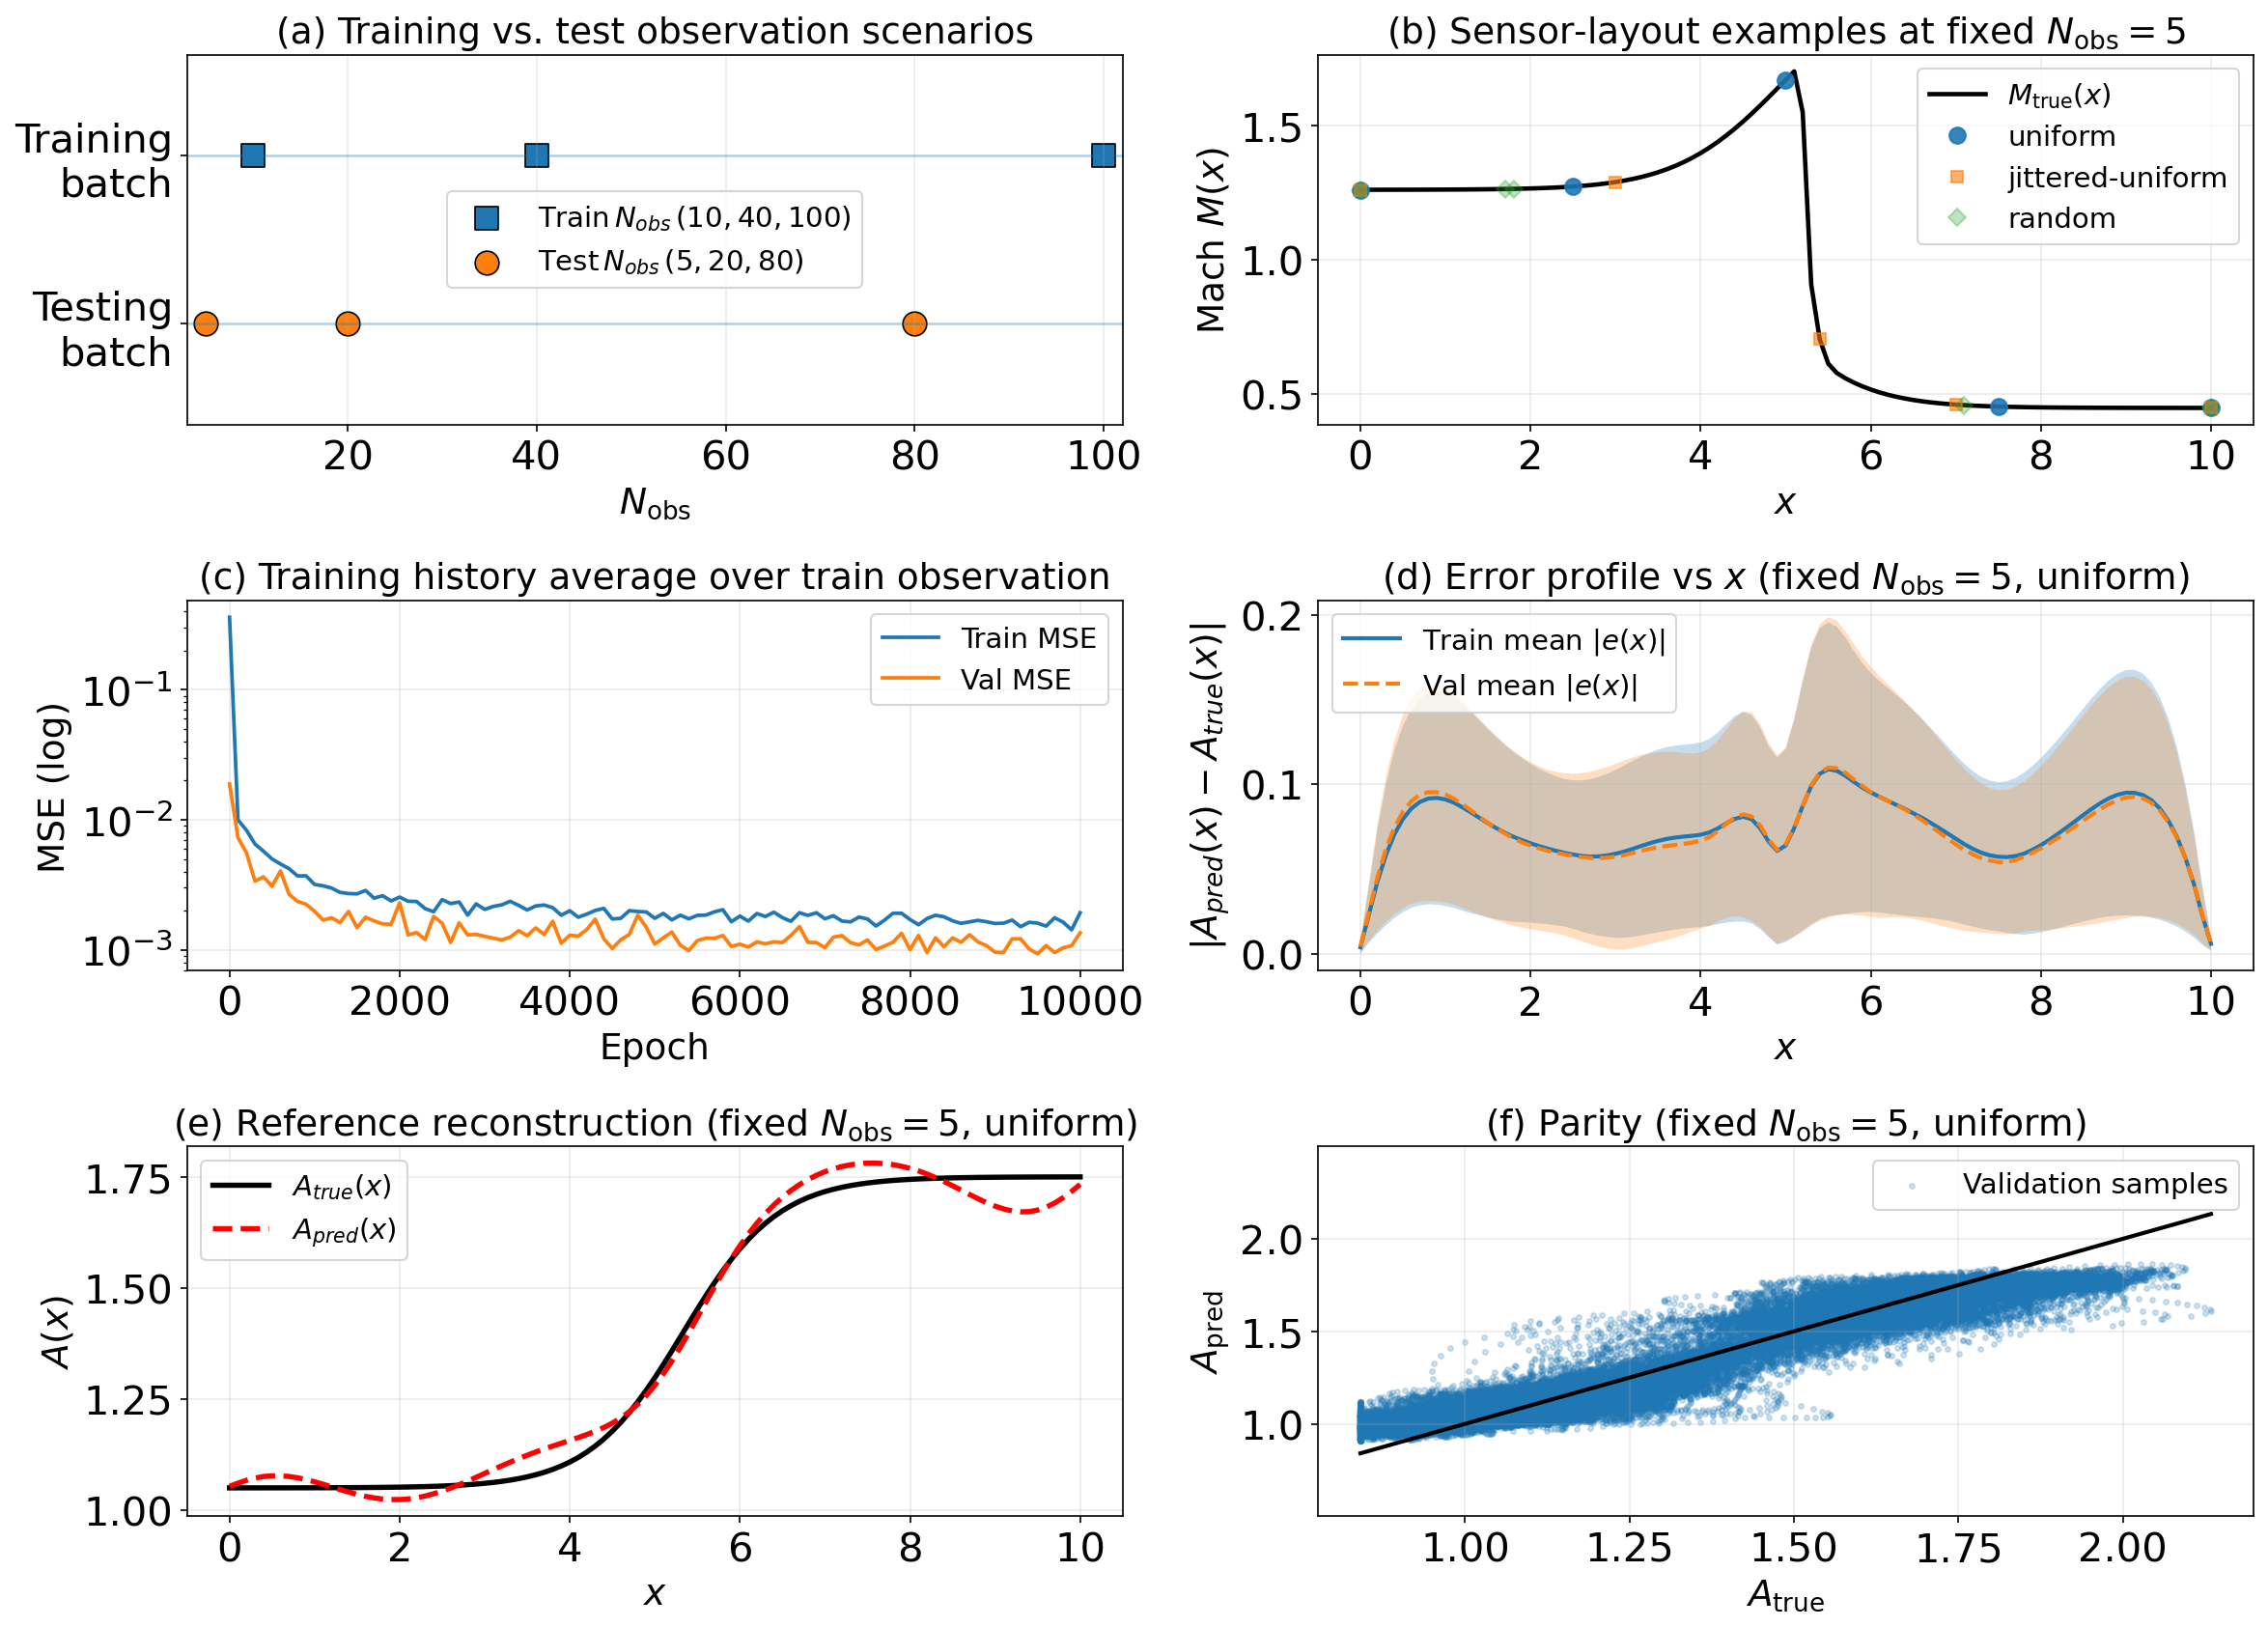

In [23]:
# -----------------------------
# Global plotting style 
# -----------------------------
plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 1.8,
    "figure.dpi": 150
})

# -----------------------------
# NEW panel (a): scenario map (train vs test)
# -----------------------------
def plot_scenario_map(ax, train_nobs, test_nobs,
                      train_patterns=("uniform", "jittered-uniform", "random"),
                      test_pattern="uniform (fixed)",
                      x_pad=2):
    """
    Clean graphic: highlights which Nobs were used in training vs held-out test/report.
    """
    train_nobs = sorted(list(train_nobs))
    test_nobs  = sorted(list(test_nobs))

    x_min = min(train_nobs + test_nobs) - x_pad
    x_max = max(train_nobs + test_nobs) + x_pad

    # y positions
    y_train = 1.0
    y_test  = 0.0

    # light baselines
    ax.hlines([y_train, y_test], x_min, x_max, lw=1.2, alpha=0.35)

    # markers
    ax.scatter(train_nobs, [y_train]*len(train_nobs),
               s=140, marker="s", edgecolor="k", linewidth=0.8, label=r"$\text{Train}\,N_{obs}\,(10, 40 ,100)$")
    ax.scatter(test_nobs,  [y_test]*len(test_nobs),
               s=140, marker="o", edgecolor="k", linewidth=0.8, label=r"$\text{Test}\,N_{obs}\,(5, 20, 80)$")
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-0.6, 1.6)
    ax.set_yticks([y_test, y_train])
    ax.set_yticklabels(["Testing\nbatch", "Training\nbatch"])
    ax.set_xlabel(r"$N_{\mathrm{obs}}$")
    ax.set_title(r"(a) Training vs. test observation scenarios")

    ax.grid(axis="x", alpha=0.25)
    ax.grid(axis="y", alpha=0.0)

    # small legend inside
    ax.legend(loc="center", frameon=True)


# ============================================================
# Figure layout (3×2)
# ============================================================
fig, axs = plt.subplots(3, 2, figsize=(16,12))
# -----------------------------
# (a) Scenario map (TRAIN vs TEST)
# -----------------------------
TRAIN_NOBS = [10, 40, 100]
TEST_REPORT_NOBS = [5, 20, 80] 
plot_scenario_map(
    axs[0, 0],
    train_nobs=TRAIN_NOBS,
    test_nobs=TEST_REPORT_NOBS,
)

# -----------------------------
# (b) Sensor-layout examples at fixed Nobs
# -----------------------------
ax = axs[0, 1]
ax.plot(x_np, M_true, "k-", lw=2.2, label=r"$M_{\mathrm{true}}(x)$")

ax.plot(x_np[idx_u], M_true[idx_u], "o", ms=8, alpha=0.9, label="uniform")
ax.plot(x_np[idx_j], M_true[idx_j], "s", ms=6, alpha=0.6, label="jittered-uniform")
ax.plot(x_np[idx_r], M_true[idx_r], "D", ms=6, alpha=0.3, label="random")

ax.set_title(rf"(b) Sensor-layout examples at fixed $N_{{\mathrm{{obs}}}}={NOBS_FIXED}$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"Mach $M(x)$")
ax.grid(alpha=0.25)
ax.legend(loc="upper right", frameon=True)

# -----------------------------
# (c) Training history
# -----------------------------
ax = axs[1, 0]
ax.set_title("(c) Training history average over train observation")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (log)")
ax.grid(alpha=0.25)
if train_curve is not None:
    ax.semilogy(epoch_curve, train_curve, label="Train MSE")
    ax.semilogy(epoch_curve, val_curve,   label="Val MSE")
    ax.legend(frameon=True)
else:
    ax.text(0.05, 0.55, "No inv_deeponet_loss_history.npz found.", transform=ax.transAxes)

# -----------------------------
# (d) Error profile vs x
# -----------------------------
ax = axs[1, 1]
ax.set_title(rf"(d) Error profile vs $x$ (fixed $N_{{\mathrm{{obs}}}}={NOBS_FIXED}$, {PATTERN_FIXED})")
ax.plot(x_np, etrain_mu, lw=2.0, label=r"Train mean $|e(x)|$")
ax.fill_between(x_np, etrain_mu - etrain_sd, etrain_mu + etrain_sd, alpha=0.25)
ax.plot(x_np, eval_mu,   "--", lw=2.0, label=r"Val mean $|e(x)|$")
ax.fill_between(x_np, eval_mu - eval_sd, eval_mu + eval_sd, alpha=0.25)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$|A_{pred}(x)-A_{true}(x)|$")
ax.grid(alpha=0.25)
ax.legend(frameon=True)

# -----------------------------
# (e) reconstruction
# -----------------------------
ax = axs[2, 0]
ax.plot(x_np, A_true_np, "k-",  lw=2.6, label=r"$A_{true}(x)$")
ax.plot(x_np, A_pred_e,  "r--", lw=2.6, label=r"$A_{pred}(x)$")

ymin = float(min(A_true_np.min(), A_pred_e.min()))
ymax = float(max(A_true_np.max(), A_pred_e.max()))
rug_h = 0.05 * (ymax - ymin + 1e-12)
# for xi in x_np[idx_e]:
#     ax.vlines(xi, ymin, ymin + rug_h, lw=1.1)

ax.set_title(
    rf"(e) Reference reconstruction (fixed $N_{{\mathrm{{obs}}}}={NOBS_FIXED}$, {PATTERN_FIXED})"
)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$A(x)$")
ax.grid(alpha=0.25)
ax.legend(loc="upper left", frameon=True)

# -----------------------------
# (f) Parity plot (Area)
# -----------------------------
ax = axs[2, 1]
ax.scatter(Atrue_flat, Apred_flat, s=6, alpha=0.20, label="Validation samples")
mn = float(min(Atrue_flat.min(), Apred_flat.min()))
mx = float(max(Atrue_flat.max(), Apred_flat.max()))
ax.plot([mn, mx], [mn, mx], "k-", lw=2.0)
ax.set_ylim(0.5, 2.5)
ax.set_yticks([1.0, 1.5, 2.0])
ax.set_title(rf"(f) Parity (fixed $N_{{\mathrm{{obs}}}}={NOBS_FIXED}$, {PATTERN_FIXED})")
ax.set_xlabel(r"$A_{\mathrm{true}}$")
ax.set_ylabel(r"$A_{\mathrm{pred}}$")
ax.grid(alpha=0.25)
ax.legend(frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.965])
plt.show()


Nobs=5
  CFD -> inverse_nozzle_bspline_5.npz
  DN  -> inverse_results_DeepONet_5obs.npz
Nobs=10
  CFD -> inverse_nozzle_bspline_100.npz
  DN  -> inverse_results_DeepONet_10obs.npz
Nobs=20
  CFD -> inverse_nozzle_bspline_20.npz
  DN  -> inverse_results_DeepONet_20obs.npz
Nobs=40
  CFD -> inverse_nozzle_bspline_40.npz
  DN  -> inverse_results_DeepONet_40obs.npz
Nobs=80
  CFD -> inverse_nozzle_bspline_80.npz
  DN  -> inverse_results_DeepONet_80obs.npz
Nobs=100
  CFD -> inverse_nozzle_bspline_100.npz
  DN  -> inverse_results_DeepONet_100obs.npz


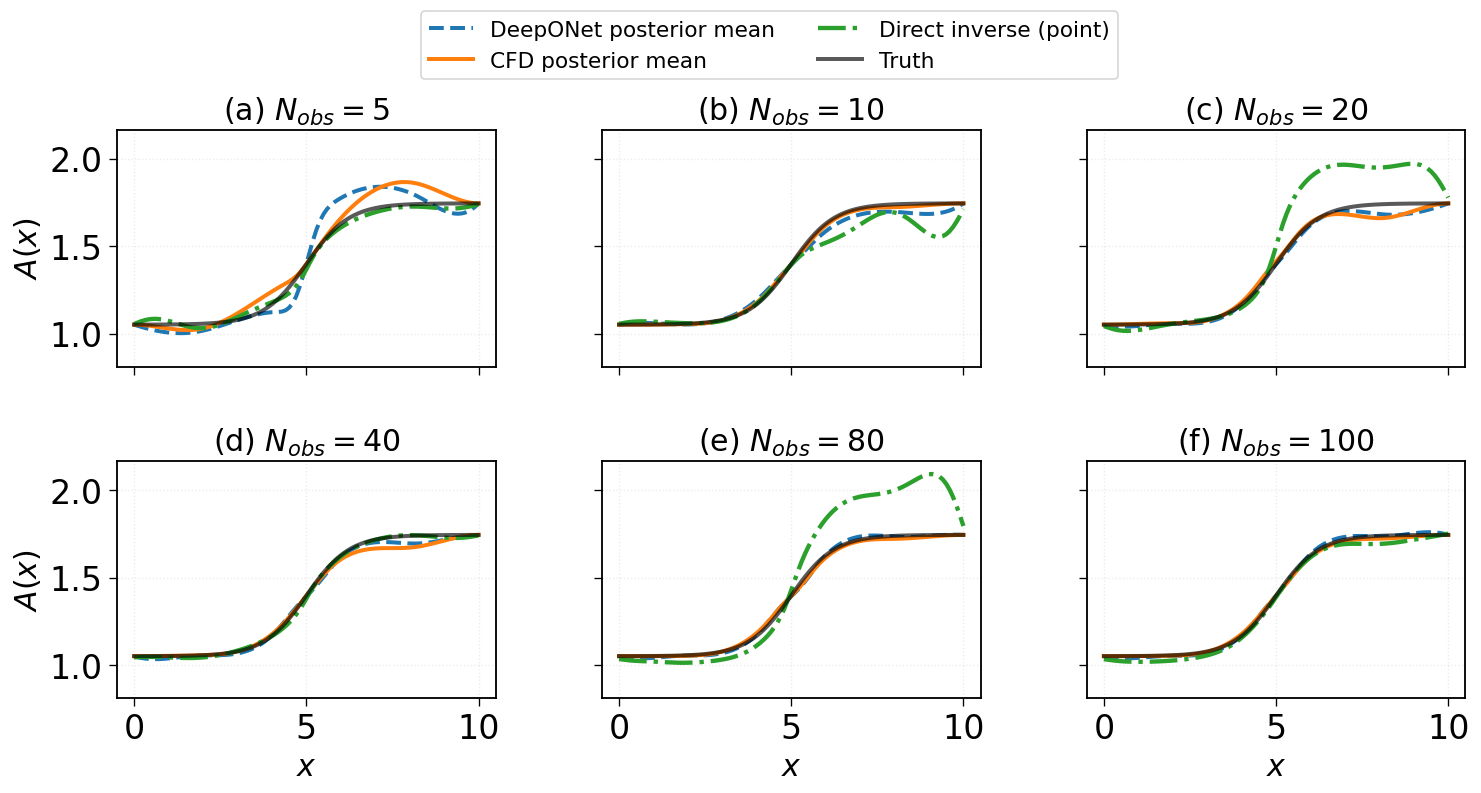

Saved: A_recon_2x3_Direct_vs_DNmean_vs_CFDmean.png


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import glob

# -----------------------------
# Style (same vibe as your compare plot)
# -----------------------------
plt.rcParams.update({
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "legend.fontsize": 13,
    "figure.dpi": 120,
    "savefig.dpi": 400,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.linewidth": 1.1,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
})

# -----------------------------
# Sensor helper (uniform)
# -----------------------------
def obs_indices_uniform(N, Nobs):
    idx = np.linspace(0, N - 1, int(Nobs)).round().astype(np.int32)
    return np.unique(idx)

def make_sparse_and_mask(M_full, idx, N):
    Msp = np.zeros((N,), dtype=np.float32)
    mk  = np.zeros((N,), dtype=np.float32)
    Msp[idx] = M_full[idx]
    mk[idx]  = 1.0
    return Msp, mk

# -----------------------------
# File helpers
# -----------------------------
def latest(pattern):
    f = sorted(glob.glob(pattern))
    assert f, f"No files matched: {pattern}"
    return f[-1]

def load_npz(path):
    d = np.load(path, allow_pickle=False)
    return {k: d[k] for k in d.files}

def ensure_bands(d, prefix):
    """
    Ensure {prefix}_lo and {prefix}_hi exist.
    Accepts either:
      - {prefix}_lo/{prefix}_hi
      - {prefix}_mu/{prefix}_sd  -> builds ±2σ band
    """
    mu = d.get(f"{prefix}_mu", None)
    sd = d.get(f"{prefix}_sd", None)
    lo = d.get(f"{prefix}_lo", None)
    hi = d.get(f"{prefix}_hi", None)

    if (lo is None) or (hi is None):
        if (mu is None) or (sd is None):
            raise KeyError(f"Need either {prefix}_lo/{prefix}_hi OR {prefix}_mu/{prefix}_sd.")
        d[f"{prefix}_lo"] = mu - 2.0 * sd
        d[f"{prefix}_hi"] = mu + 2.0 * sd

def padded_limits(arr_list, pad_frac=0.05):
    a = np.concatenate([np.ravel(np.asarray(v, dtype=np.float64)) for v in arr_list])
    lo, hi = np.min(a), np.max(a)
    pad = pad_frac * (hi - lo + 1e-12)
    return lo - pad, hi + pad

# -----------------------------
# CONFIG
# -----------------------------
NOBS = [5, 10, 20, 40, 80, 100]  # 2×3

CFD_GLOB = "inverse_nozzle_bspline_{Nobs}*.npz"
DN_FILE  = "inverse_results_DeepONet_{Nobs}obs.npz"

# Toggle shading bands (means-only comparison requested; set False if you want strictly means)
SHOW_BANDS = False

# -----------------------------
# LOAD DN + CFD (for A_true, A_mu, A_lo/hi)
# -----------------------------
DATA = {}
for Nobs in NOBS:
    cfd_path = latest(CFD_GLOB.format(Nobs=Nobs))
    dn_path  = DN_FILE.format(Nobs=Nobs)

    cfd = load_npz(cfd_path)
    dn  = load_npz(dn_path)

    ensure_bands(cfd, "A")
    ensure_bands(dn,  "A")

    DATA[Nobs] = {"CFD": cfd, "DN": dn, "cfd_path": cfd_path, "dn_path": dn_path}
    print(f"Nobs={Nobs}")
    print("  CFD ->", cfd_path)
    print("  DN  ->", dn_path)

# -----------------------------
# Compute DIRECT inverse A_dir(x) using your trained inverse operator
# Requires in your session:
#   - inv_apply_single_jit, params
# and either:
#   - DATA[Nobs]["CFD"]["M_obs_full"] exists
# OR you provide M_obs_full another way.
# -----------------------------
A_DIR = {}

for Nobs in NOBS:
    cfd = DATA[Nobs]["CFD"]

    x = np.asarray(cfd["x"], dtype=np.float32)
    N = x.size

    # We need a noisy M_obs_full on the full grid to build sparse observations.
    if "M_obs_full" in cfd:
        M_obs_full = np.asarray(cfd["M_obs_full"], dtype=np.float32)
    elif "M_obs" in cfd and len(cfd["M_obs"]) == N:
        M_obs_full = np.asarray(cfd["M_obs"], dtype=np.float32)
    else:
        # Fallback (not ideal): use truth if noisy full obs not saved
        M_obs_full = np.asarray(cfd.get("M_true", cfd.get("M_mu")), dtype=np.float32)

    idx = obs_indices_uniform(N, Nobs)
    Msp, mk = make_sparse_and_mask(M_obs_full, idx, N)

    # ---- Direct inverse prediction (point estimate)
    # NOTE: this assumes inv_apply_single_jit signature matches your first snippet.
    import jax.numpy as jnp  # local import ok
    A_pred = np.asarray(
        inv_apply_single_jit(
            params,
            jnp.asarray(Msp, dtype=jnp.float32),
            jnp.asarray(mk,  dtype=jnp.float32),
            jnp.asarray(x,   dtype=jnp.float32),
        ),
        dtype=np.float32
    )
    A_DIR[Nobs] = {"A_dir": A_pred, "idx": idx, "M_obs_full": M_obs_full}

# -----------------------------
# Consistent y-limits for A(x)
# -----------------------------
A_all = []
for Nobs in NOBS:
    cfd = DATA[Nobs]["CFD"]
    dn  = DATA[Nobs]["DN"]
    A_all += [
        cfd["A_true"], cfd["A_mu"], cfd["A_lo"], cfd["A_hi"],
        dn["A_mu"], dn["A_lo"], dn["A_hi"],
        A_DIR[Nobs]["A_dir"]
    ]
A_ylim = padded_limits(A_all, 0.06)

# -----------------------------
# Plot: 2×3 (A(x) only)
# -----------------------------
fig, axes = plt.subplots(
    2, 3, figsize=(14.5, 6.4),
    sharex=True, sharey=True,
    gridspec_kw={"wspace": 0.28, "hspace": 0.40}
)
axes = axes.ravel()
panels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]

legend_handles = None

for k, Nobs in enumerate(NOBS):
    ax = axes[k]
    cfd = DATA[Nobs]["CFD"]
    dn  = DATA[Nobs]["DN"]

    x      = np.asarray(cfd["x"], dtype=np.float64)
    A_true = np.asarray(cfd["A_true"], dtype=np.float64)

    # Optional CI bands
    if SHOW_BANDS:
        h_dn_ci = ax.fill_between(x, dn["A_lo"], dn["A_hi"], alpha=0.16, zorder=1)
        h_cfd_ci = ax.fill_between(x, cfd["A_lo"], cfd["A_hi"], alpha=0.16, zorder=1)
    else:
        h_dn_ci = None
        h_cfd_ci = None

    # Means
    h_dn_mu,  = ax.plot(x, dn["A_mu"],  lw=2.4, ls="--", zorder=3)     # DeepONet mean
    h_cfd_mu, = ax.plot(x, cfd["A_mu"], lw=2.4, zorder=3)             # CFD mean

    # Direct inverse (point estimate)
    h_dir, = ax.plot(x, A_DIR[Nobs]["A_dir"], lw=2.6, ls="-.", zorder=4)

    # Truth
    h_tr, = ax.plot(x, A_true, "k", lw=2.4, alpha=0.65, zorder=5)

    # # Sensor rug (to match your first figure’s sensor indication)
    # idx = A_DIR[Nobs]["idx"]
    # y_rug = A_ylim[0] + 0.02*(A_ylim[1]-A_ylim[0])
    # ax.scatter(x[idx], np.full(idx.shape, y_rug), s=16, alpha=0.9, zorder=6)

    ax.set_title(rf"{panels[k]} $N_{{obs}}={Nobs}$", pad=6)
    ax.grid(True)
    ax.set_ylim(*A_ylim)

    if (k % 3) == 0:
        ax.set_ylabel(r"$A(x)$")

    if k >= 3:
        ax.set_xlabel(r"$x$")

    # Save handles for a shared legend
    if legend_handles is None:
        if SHOW_BANDS:
            legend_handles = (h_dn_ci, h_dn_mu, h_cfd_ci, h_cfd_mu, h_dir, h_tr)
        else:
            legend_handles = (h_dn_mu, h_cfd_mu, h_dir, h_tr)

# -----------------------------
# Shared legend
# -----------------------------
if SHOW_BANDS:
    labels = ["DeepONet 95% CI", "DeepONet posterior mean",
              "CFD 95% CI", "CFD posterior mean",
              "Direct inverse (point)", "Truth"]
    ncol = 3
else:
    labels = ["DeepONet posterior mean", "CFD posterior mean",
              "Direct inverse (point)", "Truth"]
    ncol = 2

fig.legend(
    legend_handles, labels,
    loc="upper center", ncol=ncol,
    frameon=True, bbox_to_anchor=(0.5, 1.01),
    borderaxespad=0.2
)

fig.subplots_adjust(top=0.85)

out_png = "A_recon_2x3_Direct_vs_DNmean_vs_CFDmean.png"
plt.savefig(out_png, bbox_inches="tight")
plt.show()
print("Saved:", out_png)
